# Lee 2002

In [55]:
# imports
import numpy as np
from importlib import reload

import seaborn as sns
from matplotlib import pyplot as plt
import pandas

from ocpy.hydrolight import loisel23
from ocpy.utils import plotting

from bing import rt

from xqaa import geometric as xqaa_geom

# Load

In [2]:
l23_ds = loisel23.load_ds(1,0)

## Unpack

In [19]:
l23_wave = l23_ds.Lambda.data
l23_Rrs = l23_ds.Rrs.data
l23_bbnw = l23_ds.bbnw.data
l23_anw = l23_ds.anw.data
l23_a = l23_ds.a.data

In [42]:
nspec = l23_a.shape[0]
nspec

3320

## Specific wavelengths

In [21]:
i440 = np.argmin(np.abs(l23_wave-440.))
i555 = np.argmin(np.abs(l23_wave-555.))

## Water

In [4]:
aw = (l23_ds.a.data - l23_ds.anw.data)[0]
bbw = (l23_ds.bb.data - l23_ds.bbnw.data)[0]

# Step 0

In [9]:
l23_rrs = xqaa_geom.rrs_from_Rrs(l23_Rrs)
l23_rrs.shape

(3320, 81)

# Step 1

In [13]:
def u_from_r(rrs, g0=0.0895, g1=0.1247):
    u = (-g0 + np.sqrt(g0**2 + 4*g1*rrs))/(2*g1)
    return u

In [14]:
l23_u = u_from_r(l23_rrs)

# Step 2 (Emprical)

In [22]:
def a555_from_rrs_440_555(rrs):
    # rho
    rho = np.log(rrs[:,i440] / rrs[:,i555])
    # a440_i
    a440_i = np.exp(-2. - 1.4*rho + 0.2*rho**2)
    # a550
    a555 = aw[i555] + 0.2*(a440_i - 0.01)
    #
    return a555

In [43]:
qaa_a555 = a555_from_rrs_440_555(l23_rrs)

## Check me

In [24]:
l23_a555 = l23_a[:,i555]

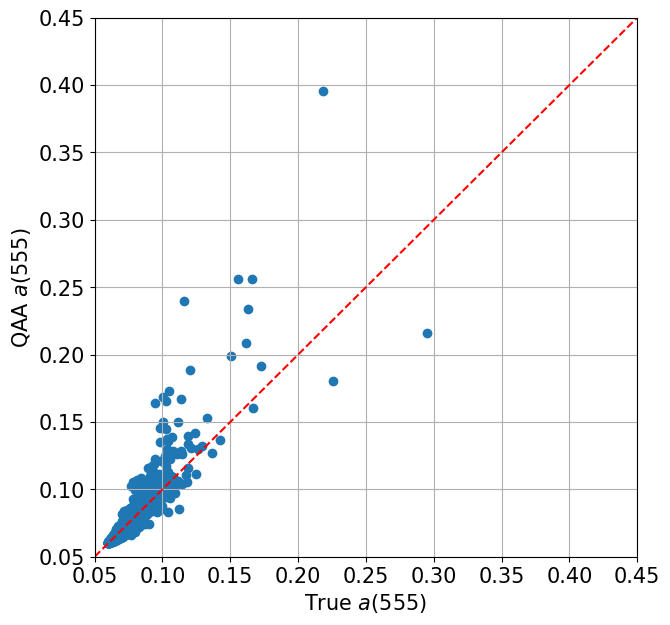

In [68]:
fig = plt.figure(figsize=(7,7))
ax = plt.gca()
ax.scatter(l23_a555, qaa_a555)
#
ax.set_xlabel(r'True $a(555)$')
ax.set_ylabel(r'QAA $a(555)$')
ax.grid()
# 1-1
xmin, xmax = 5e-2, 0.45
ax.set_xlim(xmin,xmax)
ax.set_ylim(xmin,xmax)
ax.plot([xmin,xmax], [xmin,xmax], 'r--', label='1 to 1')
#
#ax.set_xscale('log')
#ax.set_yscale('log')
# 
plotting.set_fontsize(ax, 15)
#
plt.show()

## Bins of RMS

In [69]:
nspec/83

40.0

In [89]:
def calc_avgrms(l23, qaa):
    isrt = np.argsort(l23)
    avg, rms= [], []
    for ss in range(40):
        i0 = ss*83
        i1 = i0 + 83
        #
        sub = l23[isrt][i0:i1]
        qsub = qaa[isrt][i0:i1]
        avg.append(np.mean(sub))
        rms.append(np.std(sub-qsub))
    #
    return np.array(avg), np.array(rms)
    #df = pandas.DataFrame()
    #df['avg'] = av_a555
    #df['rms'] = rms_qaa
    #df

In [90]:
def plt_perc_error(l23, qaa, var:str):
    fig = plt.figure(figsize=(7,7))
    ax = plt.gca()
    ax.scatter(l23, 100*(qaa-l23)/l23, color='g')
    # Bins of RMS
    avg, rms= calc_avgrms(l23, qaa)
    ax.plot(avg, 100*rms/avg, 'rs')
    #
    ax.set_xlabel(r'True $'+f'{var}'+r'$')
    ax.set_ylabel('QAA Percent Error')
    # 0
    ax.axhline(0., color='gray', ls='--')
    #ax.axvline(aw[i555], color='b', ls=':')
    ax.grid()
    #ax.set_xlim(xmin,xmax)
    #ax.set_ylim(xmin,xmax)
    #ax.plot([xmin,xmax], [xmin,xmax], 'r--', label='1 to 1')
    ax.set_xscale('log')
    #ax.set_yscale('log')
    # 
    plotting.set_fontsize(ax, 15)
    return ax

<Axes: xlabel='True $a(555)$', ylabel='QAA Percent Error'>

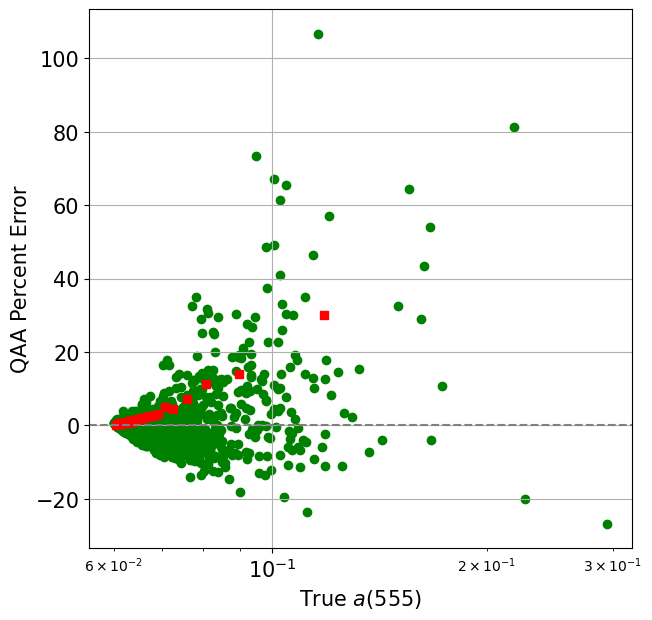

In [91]:
plt_perc_error(l23_a555, qaa_a555, 'a(555)')

# Step 3

In [72]:
qaa_bbp_555 = l23_u[:,i555]*qaa_a555 / (1. - l23_u[:,i555]) - bbw[i555]

In [74]:
l23_bbp555 = l23_bbnw[:,i555]

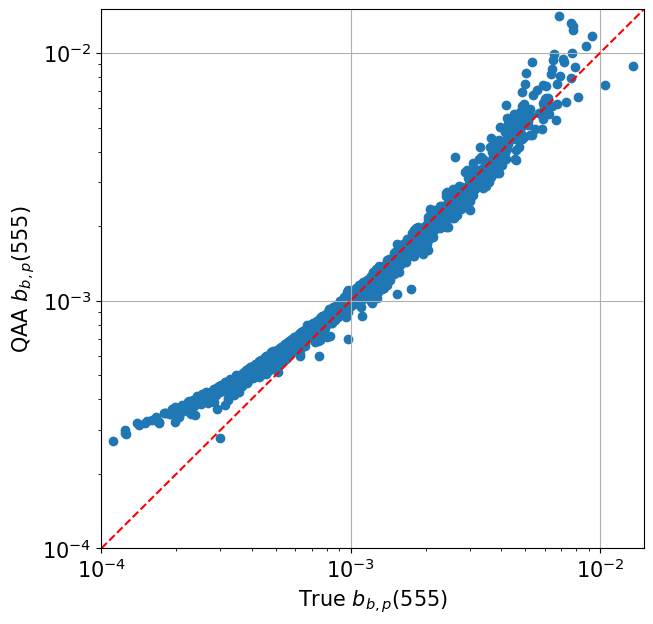

In [82]:
fig = plt.figure(figsize=(7,7))
ax = plt.gca()
ax.scatter(l23_bbp555, qaa_bbp_555)
#
ax.set_xlabel(r'True $b_{b,p}(555)$')
ax.set_ylabel(r'QAA $b_{b,p}(555)$')
ax.grid()
# 1-1
xmin, xmax = 1e-4, 0.015
ax.set_xlim(xmin,xmax)
ax.set_ylim(xmin,xmax)
ax.plot([xmin,xmax], [xmin,xmax], 'r--', label='1 to 1')
#
ax.set_xscale('log')
ax.set_yscale('log')
# 
plotting.set_fontsize(ax, 15)
#
plt.show()

<Axes: xlabel='True $b_{b,p}(555)$', ylabel='QAA Percent Error'>

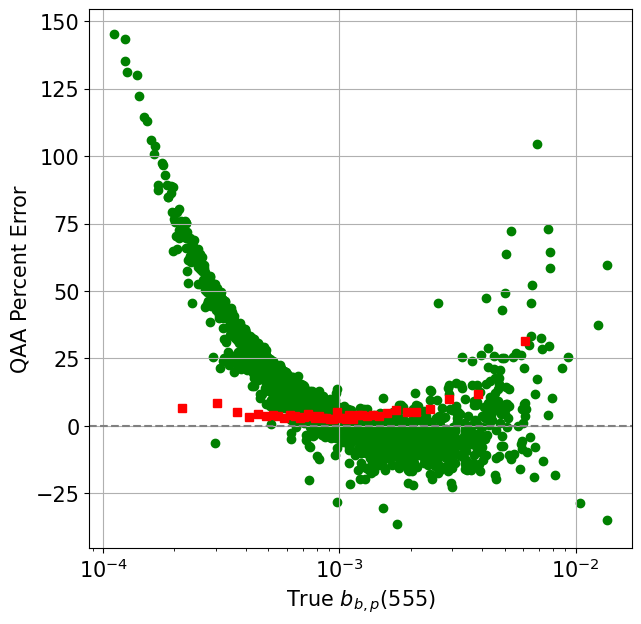

In [92]:
plt_perc_error(l23_bbp555, qaa_bbp_555, 'b_{b,p}(555)')

# Step 4